# Image Blending via Feature Matching

### Import Required Libraries

In [19]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

### Read Normal-Light and Low-Light Images

In [4]:
normal_light_image = cv2.imread("Documents/AIML-Assessment/Module-2/raw_captures/Capture_1.jpeg")
low_light_image = cv2.imread("Documents/AIML-Assessment/Module-2/raw_captures/Capture_2.jpeg")

In [5]:
nl_img_rgb = cv2.cvtColor(normal_light_image,cv2.COLOR_BGR2RGB)
ll_img_rgb = cv2.cvtColor(low_light_image,cv2.COLOR_BGR2RGB)

In [6]:
nl_img_gray = cv2.cvtColor(normal_light_image, cv2.COLOR_BGR2GRAY)
ll_img_gray = cv2.cvtColor(low_light_image, cv2.COLOR_BGR2GRAY)

(np.float64(-0.5), np.float64(1199.5), np.float64(1599.5), np.float64(-0.5))

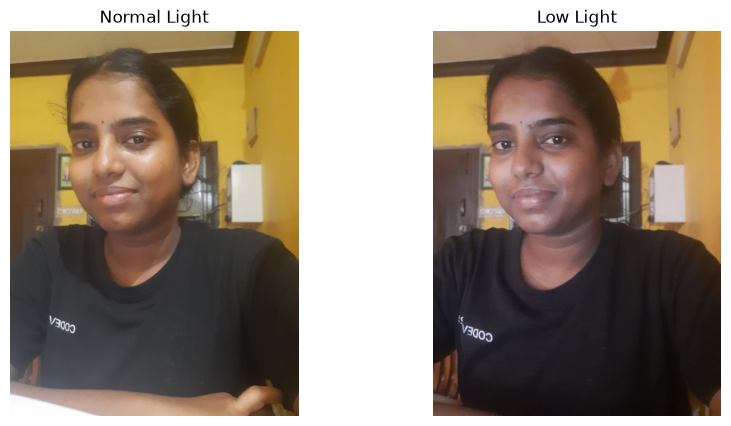

In [61]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
axes[0].imshow(nl_img_rgb)
axes[0].set_title("Normal Light")
axes[0].axis('off')
axes[1].imshow(ll_img_rgb)
axes[1].set_title("Low Light")
axes[1].axis('off')

### Detect ORB Features & Compute Descriptors

In [35]:
MAX_NUM_FEATURES = 2000
orb = cv2.ORB_create(MAX_NUM_FEATURES)
keypoints1, descriptors1 = orb.detectAndCompute(nl_img_gray, None)
keypoints2, descriptors2 = orb.detectAndCompute(ll_img_gray, None)

In [36]:
nl_display = cv2.drawKeypoints(nl_img_rgb, keypoints=keypoints1, outImage=None, color=(0,255,0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
ll_display = cv2.drawKeypoints(ll_img_rgb, keypoints=keypoints2, outImage=None, color=(0,255,0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

(np.float64(-0.5), np.float64(1199.5), np.float64(1599.5), np.float64(-0.5))

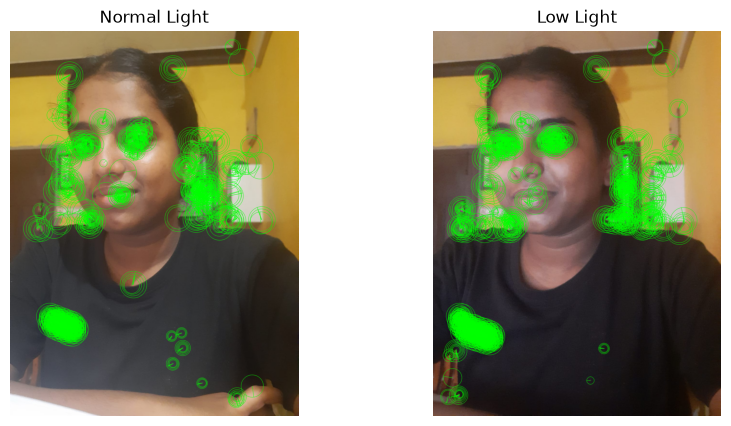

In [62]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
axes[0].imshow(nl_display)
axes[0].set_title("Normal Light")
axes[0].axis('off')
axes[1].imshow(ll_display)
axes[1].set_title("Low Light")
axes[1].axis('off')

### Match Keypoints in the Two Images

In [39]:
matcher = cv2.DescriptorMatcher_create(cv2.DESCRIPTOR_MATCHER_BRUTEFORCE_HAMMING)
matches = list(matcher.match(descriptors1,descriptors2))
matches.sort(key=lambda x:x.distance, reverse=False)

### Good Matches

In [40]:
numGoodMatches = int(len(matches) * 0.04)
good_matches = matches[:numGoodMatches]

(np.float64(-0.5), np.float64(2399.5), np.float64(1599.5), np.float64(-0.5))

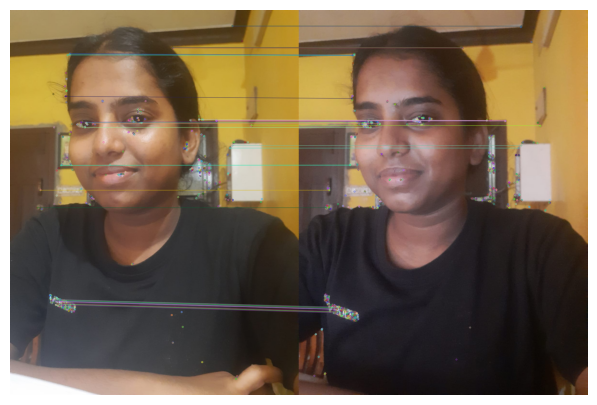

In [63]:
im_matches = cv2.drawMatches(nl_img_rgb,keypoints1,ll_img_rgb,keypoints2,good_matches,None)
plt.figure(figsize=(10,5))
plt.imshow(im_matches)
plt.axis('off')

### Find Homography

In [48]:
points1 = []
points2 = []
for match in good_matches:
    idx1 = match.queryIdx
    idx2 = match.trainIdx
    (x1,y1) = keypoints1[idx1].pt
    (x2,y2) = keypoints2[idx2].pt
    points1.append((x1,y1))
    points2.append((x2,y2))
points1 = np.float32(points1).reshape(-1, 1, 2)
points2 = np.float32(points2).reshape(-1, 1, 2) 

In [55]:
h, mask = cv2.findHomography(points2,points1,cv2.RANSAC)

### Warp Image

(np.float64(-0.5), np.float64(1199.5), np.float64(1599.5), np.float64(-0.5))

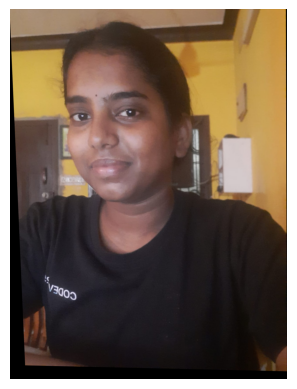

In [64]:
height, width, channels = nl_img_rgb.shape
result = cv2.warpPerspective(ll_img_rgb, h, (width,height))
plt.imshow(result)
plt.axis('off')

In [ ]:
### Blend T

(np.float64(-0.5), np.float64(1199.5), np.float64(1599.5), np.float64(-0.5))

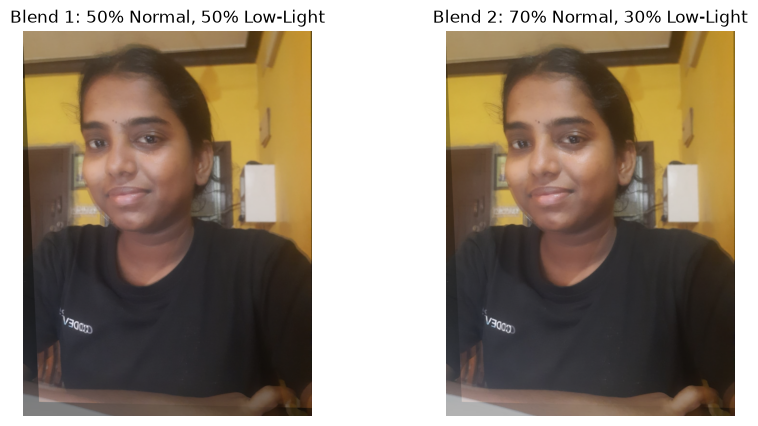

In [65]:
blend_1 = cv2.addWeighted(nl_img_rgb,0.5,result,0.5,0)
blend_2 = cv2.addWeighted(nl_img_rgb,0.7,result,0.3,0)
fig, axes = plt.subplots(1,2,figsize=(10,5))
axes[0].imshow(blend_1)
axes[0].set_title("Blend 1: 50% Normal, 50% Low-Light")
axes[0].axis('off')
axes[1].imshow(blend_2)
axes[1].set_title("Blend 2: 70% Normal, 30% Low-Light")
axes[1].axis('off')

In [67]:
print(f"Total Good Matches Found: {len(good_matches)}")

Total Good Matches Found: 39


Looking closely at the output, distinct edges such as facial features, text on clothing, and background structural lines overlap cleanly without noticeable ghosting, double-edges, or blurriness. The presence of thin black borders along the left and bottom edges of the warped result confirms that the homography correctly compensated for a slight camera translation and rotation that occurred between the normal-light and low-light captures.